In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mc
import matplotlib.patches as mp
import dvx_ext
dvx_ext.build_type()

'Release'

0.0625
Length:  4.856607351795051


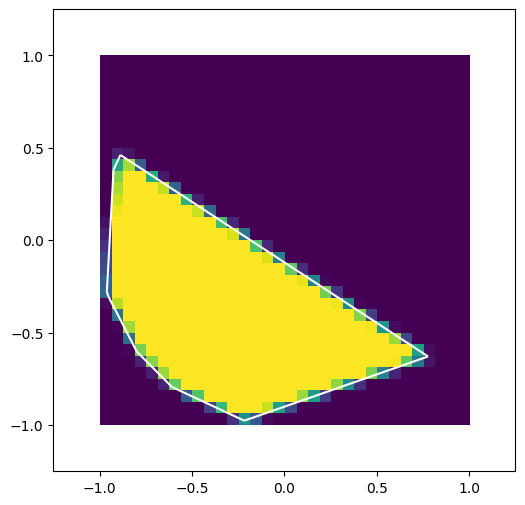

In [2]:
dim = 32

np.random.seed(0)
φ = np.sort(np.random.rand(8) * 2 * np.pi)
vertices = np.stack([np.cos(φ), np.sin(φ)], axis=-1)
edges    = np.arange(len(φ)) 
edges    = np.stack([edges, np.roll(edges, -1)], axis=-1)

occupancy = np.zeros((dim, dim), dtype=np.float32)
filter_radius = (2 / occupancy.shape[0])/2
dvx_ext.voxelize_f32(vertices, edges, occupancy, num_samples_per_voxel=1024, filter_radius=filter_radius)

print(2 / occupancy.shape[0])

print("Length: ", np.linalg.norm(vertices[edges][:, 1] - vertices[edges][:, 0], axis=-1).sum())

domain_scale = 1.25
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_ylim(-1*domain_scale, 1*domain_scale)
ax.set_xlim(-1*domain_scale, 1*domain_scale)
ax.add_collection(mc.LineCollection(vertices[edges], color='white'))
ax.imshow(occupancy, vmin=0, vmax=1, extent=(-1, 1, 1, -1))

In [3]:
vertex_id = 0

d_vertices = np.zeros_like(vertices, dtype=np.float32)
d_vertices[vertex_id, 0] = 1

# Finite differences
ε = 1e-2
occupancy_fwd = np.zeros((dim, dim), dtype=np.float32)
dvx_ext.voxelize_f32(vertices + ε * d_vertices, edges, occupancy_fwd, num_samples_per_voxel=4096, filter_radius=filter_radius)
occupancy_bwd = np.zeros((dim, dim), dtype=np.float32)
dvx_ext.voxelize_f32(vertices - ε * d_vertices, edges, occupancy_bwd, num_samples_per_voxel=4096, filter_radius=filter_radius)
d_occupancy_fd = (occupancy_fwd - occupancy_bwd) / (2 * ε)

r = np.quantile(np.abs(d_occupancy_fd), q=0.999)

0.9993767


C:\Users\mworchel\AppData\Local\Temp\ipykernel_83084\2504851269.py:5: RuntimeWarning: divide by zero encountered in divide
  ratio = (d_occupancy_fd / d_occupancy)
C:\Users\mworchel\AppData\Local\Temp\ipykernel_83084\2504851269.py:5: RuntimeWarning: invalid value encountered in divide
  ratio = (d_occupancy_fd / d_occupancy)


Text(0.5, 1.0, 'Finite Differences')

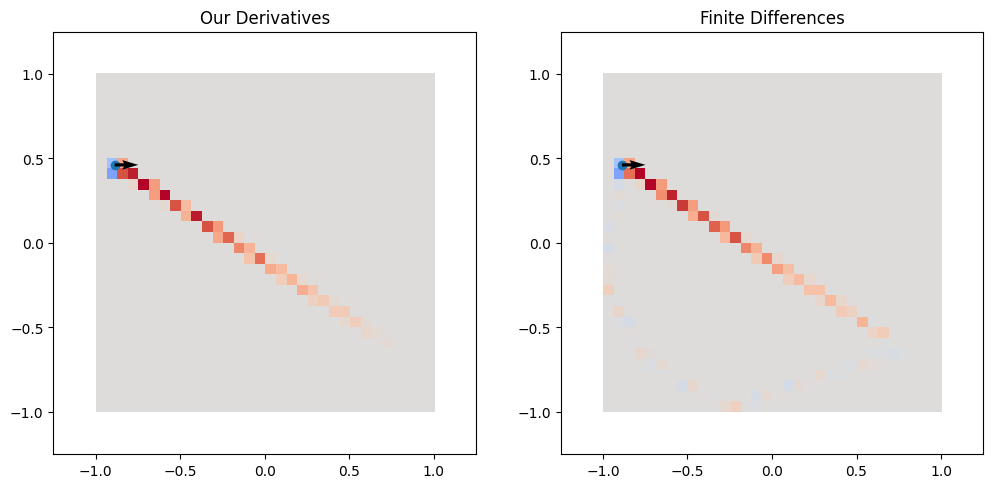

In [4]:
occupancy   = np.zeros((dim, dim), dtype=np.float32)
d_occupancy = np.zeros((dim, dim), dtype=np.float32)
dvx_ext.voxelize_forward_f32(vertices, edges, occupancy, d_vertices, d_occupancy, num_samples_per_simplex=1024, filter_radius=filter_radius)

ratio = (d_occupancy_fd / d_occupancy)
print(np.median(ratio[np.isfinite(ratio)]))

domain_scale = 1.25
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i in range(2):
    axs[i].set_ylim(-1*domain_scale, 1*domain_scale)
    axs[i].set_xlim(-1*domain_scale, 1*domain_scale)
    axs[i].scatter(*vertices[vertex_id:vertex_id+1].T)
    axs[i].quiver(*vertices[vertex_id:vertex_id+1].T, *d_vertices[vertex_id:vertex_id+1].T)
axs[0].imshow(d_occupancy, extent=(-1, 1, 1, -1), vmin=-r, vmax=r, cmap='coolwarm')
axs[0].set_title("Our Derivatives")
axs[1].imshow(d_occupancy_fd, extent=(-1, 1, 1, -1), vmin=-r, vmax=r, cmap='coolwarm')
axs[1].set_title("Finite Differences")